# Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Datasets/Returns_Data.csv")

df.head()


,SKU,Return Quantity \n(Last 7 days),Return Quantity \n(Last 30 days),Return Quantity \n(Last 60 days),Return Quantity \n(Last 90 days)
0,MN-01,0,9,18,26
1,MN-02,0,4,14,24
2,MN-03,1,4,10,13
3,MN-04,1,4,6,16
4,MN-09,0,2,7,11


# Understand the Dataset Structure

In [2]:
df.shape

(50, 5)

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   SKU                              50 non-null     object
 1   Return Quantity 
(Last 7 days)   50 non-null     object
 2   Return Quantity 
(Last 30 days)  50 non-null     int64 
 3   Return Quantity 
(Last 60 days)  50 non-null     int64 
 4   Return Quantity 
(Last 90 days)  50 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.1+ KB


In [4]:
df.columns  

Index(['SKU', 'Return Quantity \n(Last 7 days)',
       'Return Quantity \n(Last 30 days)', 'Return Quantity \n(Last 60 days)',
       'Return Quantity \n(Last 90 days)'],
      dtype='object')

# Clean Column Names

In [5]:
df.columns = [
    "SKU",
    "Return_7_days",
    "Return_30_days",
    "Return_60_days",
    "Return_90_days"
]

df.head()


,SKU,Return_7_days,Return_30_days,Return_60_days,Return_90_days
0,MN-01,0,9,18,26
1,MN-02,0,4,14,24
2,MN-03,1,4,10,13
3,MN-04,1,4,6,16
4,MN-09,0,2,7,11


# Data Type Cleaning

In [6]:
df["Return_7_days"] = pd.to_numeric(df["Return_7_days"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SKU             50 non-null     object 
 1   Return_7_days   49 non-null     float64
 2   Return_30_days  50 non-null     int64  
 3   Return_60_days  50 non-null     int64  
 4   Return_90_days  50 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 2.1+ KB


# Check Missing Values

In [7]:
df.isnull().sum()


SKU               0
Return_7_days     1
Return_30_days    0
Return_60_days    0
Return_90_days    0
dtype: int64

In [8]:
df.fillna(0, inplace=True)

# Basic Statistical Analysis

In [9]:
df.describe()

,Return_7_days,Return_30_days,Return_60_days,Return_90_days
count,50.000000,50.000000,50.000000,50.000000
mean,4.980000,16.880000,32.080000,47.180000
std,5.497643,18.481806,33.580145,47.963715
min,0.000000,1.000000,2.000000,3.000000
25%,1.000000,4.000000,11.000000,16.000000
50%,2.500000,9.500000,19.000000,28.000000
75%,7.000000,21.750000,40.000000,58.500000
max,23.000000,79.000000,142.000000,237.000000


# Total Returns per SKU

In [10]:
df["Total_Returns"] = (
    df["Return_7_days"] +
    df["Return_30_days"] +
    df["Return_60_days"] +
    df["Return_90_days"]
)

df.sort_values("Total_Returns", ascending=False).head(10)


,SKU,Return_7_days,Return_30_days,Return_60_days,Return_90_days,Total_Returns
25,MN-29,16.0,72,142,237,467.0
21,MN-25,21.0,73,126,167,387.0
10,MN-14,23.0,79,112,145,359.0
24,MN-28,11.0,45,101,137,294.0
22,MN-26,12.0,30,99,119,260.0
11,MN-15,16.0,44,79,111,250.0
36,MN-40,9.0,38,63,98,208.0
32,MN-36,6.0,36,68,96,206.0
38,MN-42,5.0,28,48,83,164.0
16,MN-20,8.0,22,51,81,162.0


# Visualize Returns by Time Period

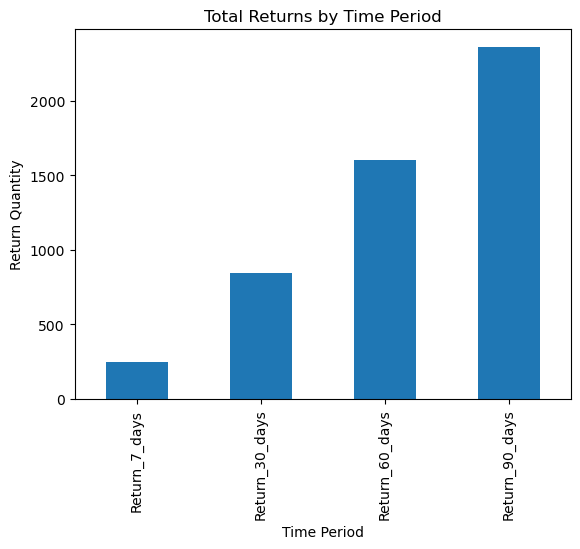

In [11]:
returns_sum = df[
    ["Return_7_days", "Return_30_days", "Return_60_days", "Return_90_days"]
].sum()

plt.figure()
returns_sum.plot(kind="bar")
plt.title("Total Returns by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Return Quantity")
plt.show()

# SKU-wise Return Comparison (Top 10)

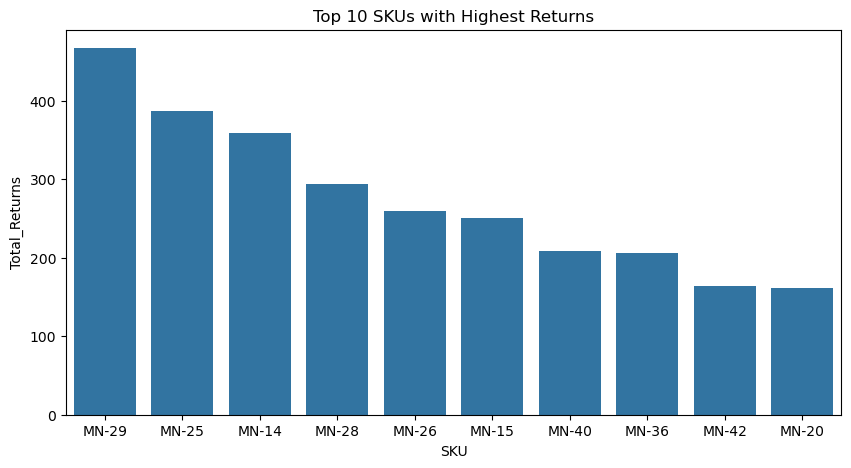

In [12]:
top_skus = df.sort_values("Total_Returns", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_skus,
    x="SKU",
    y="Total_Returns"
)
plt.title("Top 10 SKUs with Highest Returns")
plt.show()

# Trend Analysis (Returns Growth)

In [13]:
df["Return_Growth"] = df["Return_90_days"] - df["Return_7_days"]
df.sort_values("Return_Growth", ascending=False).head()

,SKU,Return_7_days,Return_30_days,Return_60_days,Return_90_days,Total_Returns,Return_Growth
25,MN-29,16.0,72,142,237,467.0,221.0
21,MN-25,21.0,73,126,167,387.0,146.0
24,MN-28,11.0,45,101,137,294.0,126.0
10,MN-14,23.0,79,112,145,359.0,122.0
22,MN-26,12.0,30,99,119,260.0,107.0


# Correlation Analysis

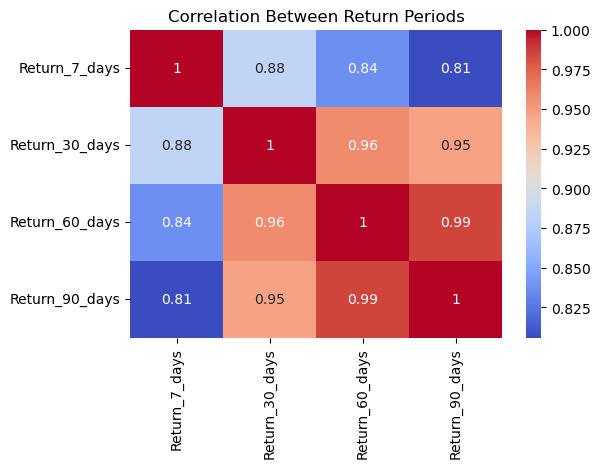

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["Return_7_days","Return_30_days","Return_60_days","Return_90_days"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Return Periods")
plt.show()

In [15]:
df.to_csv("cleaned_Returns_data.csv", index=False)